### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [4]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

# Using an explicit ChatGroq object (instead of a plain "groq:..." string) so we can
# control temperature and retry behavior.
#
# Switched to "openai/gpt-oss-20b": deepagents exposes a fairly large tool set
# (ls, read_file, write_file, edit_file, glob, grep, execute, task, write_todos).
# Both llama-3.3-70b-versatile and llama-3.1-8b-instant struggled with this many
# tools (hallucinated tool calls / malformed "tool_use_failed" generations).
# gpt-oss-20b is purpose-built by OpenAI for agentic tool-calling and is much
# more reliable here, while still being free-tier on Groq.
#
# max_retries lets the client automatically wait and retry a few times if a 429
# (rate limit) response comes back, instead of crashing the cell immediately.
from langchain_groq import ChatGroq

groq_model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_retries=6,
)

#### Context Engineering- Input context- System Prompt

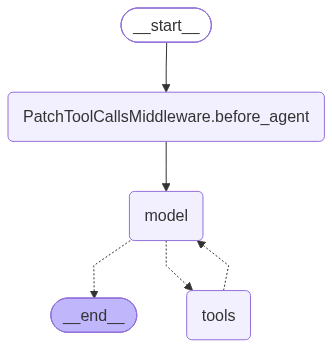

In [5]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources based only on the information given to you in the conversation. "
        "Do not attempt to call any search tools, since none are available to you right now."
    ),
)
agent

In [6]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='e462ceea-59e5-4b2c-a132-ba835ac39b0f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is deepagent?" We need to answer. We must cite sources based only on information given in the conversation. We have no prior context. We need to search the filesystem for any mention of "deepagent". Let\'s list files.', 'tool_calls': [{'id': 'fc_c46a1885-0d88-440f-b578-cd95e98bd428', 'function': {'arguments': '{"path":"/"}', 'name': 'ls'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 1677, 'total_tokens': 1753, 'completion_time': 0.079432346, 'completion_tokens_details': {'reasoning_tokens': 53}, 'prompt_time': 0.085362566, 'prompt_tokens_details': None, 'queue_time': 0.193613387, 'total_time': 0.164794912}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_2b688e7cc3', 'service_tier': 'on_dem

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

In [7]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# Project Guide\n\n## Who you are\nYou are a helpful, careful AI assistant working on the Deep Agents learning project.\nYou help with research, coding questions, and general problem solving.\n\n## How you should behave\n- Always be concise and clear in your answers.\n- Cite sources or reasoning when you make factual claims, based only on information given to you in the conversation or files you have read.\n- Do not attempt to call tools that have not been explicitly provided to you.\n- When you are unsure about something, say so instead of guessing.\n- Prefer step-by-step explanations for technical topics.\n\n## Project context\nThis is a learning project for understanding deep agents, context engineering,\nmemory backends, and skills using the `deepagents` framework with Groq models.\n'

In [8]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [9]:
agent = create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am a helpful, careful AI assistant working on the Deep Agents learning project.  
I’ll assist with research, coding questions, and general problem‑solving while:

* staying concise and clear  
* citing sources or reasoning only from the conversation or files I’ve read  
* never invoking tools that haven’t been explicitly provided  
* admitting uncertainty instead of guessing  
* using step‑by‑step explanations for technical topics whenever appropriate.


In [10]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)


In [11]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Project Guide\n\n## Who you are\nYou are a helpful, careful AI assistant working on the Deep Agents learning project.\nYou help with research, coding questions, and general problem solving.\n\n## How you should behave\n- Always be concise and clear in your answers.\n- Cite sources or reasoning when you make factual claims, based only on information given to you in the conversation or files you have read.\n- Do not attempt to call tools that have not been explicitly provided to you.\n- When you are unsure about something, say so instead of guessing.\n- Prefer step-by-step explanations for technical topics.\n\n## Project context\nThis is a learning project for understanding deep agents, context engineering,\nmemory backends, and skills using the `deepagents` framework with Groq models.\n',
 'encoding': 'utf-8',
 'created_at': '2026-08-13T21:12:02.809712+00:00',
 'modified_at': '2026-08-13T21:12:02.809712+00:00'}

In [12]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a helpful AI assistant built for the Deep Agents learning project.  
My role is to help with research, coding questions, and general problem‑solving around the `deepagents` framework and Groq models.  
I’m guided by the project guide in the `<agent_memory>` file, which reminds me to:

* Keep answers concise and clear.  
* Cite sources or reasoning only from the conversation or files I’ve read.  
* Avoid guessing—say “I’m not sure” if needed.  
* Prefer step‑by‑step explanations for technical topics.  

That’s the core of what’s stored in my memory.


In [13]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

I’m ChatGPT, a large‑language‑model trained by OpenAI. I don’t have a personal “memory” of past conversations unless you explicitly ask me to store something (for example, by using the `edit_file` tool to write data to a file). In this session I only know what you tell me or what I can read from the filesystem with the tools I have. If you’d like me to remember something for future turns, just let me know and I’ll save it in a file.


In [14]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='3c68e72a-907a-48ab-9239-958618d2a778'),
  AIMessage(content='I’m ChatGPT, a large‑language‑model trained by OpenAI. I don’t have a personal “memory” of past conversations unless you explicitly ask me to store something (for example, by using the `edit_file` tool to write data to a file). In this session I only know what you tell me or what I can read from the filesystem with the tools I have. If you’d like me to remember something for future turns, just let me know and I’ll save it in a file.', additional_kwargs={'reasoning_content': 'User asks: "What\'s in your memory? Who are you?" We need to respond. According to guidelines, we should not reveal internal memory content. We can say we are an AI assistant. We can mention we have no memory of prior interactions unless stored. We can say we have no personal memory. We can mention we can store knowledge via edit_file.

In [15]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I’m a helpful, careful AI assistant working on the Deep Agents learning project.  
My memory contains the project guide (the `AGENTS.md` file) which tells me:

- I should be concise, clear, and cite sources only from what I’ve read.  
- I must not call tools unless they’re explicitly provided.  
- I should admit uncertainty instead of guessing and give step‑by‑step explanations for technical topics.  
- The project is about learning deep agents, context engineering, memory backends, and skills with the `deepagents` framework and Groq models.


In [16]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I’m not familiar with a term called **“LLM Gateways”** in the context of this project. Could you provide more details or point me to where it’s mentioned? That way I can give you a precise answer.


#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [17]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}


In [18]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [19]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '# LangGraph Skill\n\n## When to use this skill\nUse this skill whenever the user asks about building agent graphs, state machines,\nconditional routing, memory/checkpointing, or anything related to the LangGraph\nlibrary.\n\n## Key concepts\n- A LangGraph `StateGraph` is built from nodes (functions) and edges (transitions).\n- State is a typed dictionary (or Pydantic model) shared across nodes.\n- Conditional edges route to different nodes based on a function that inspects state.\n- A `checkpointer` (e.g. `MemorySaver`) persists state across turns using a `thread_id`.\n\n## Minimal example\n```python\nfrom langgraph.graph import StateGraph, END\nfrom typing import TypedDict\n\nclass State(TypedDict):\n    count: int\n\ndef increment(state: State) -> State:\n    return {"count": state["count"] + 1}\n\ndef should_continue(state: State) -> str:\n    return "increment" if state["count"] < 3 else END\n\ngraph = StateGraph(State)\ngraph.add_node("i

In [21]:
agent=create_deep_agent(
    model=groq_model,
    subagents=[{"name": "general-purpose", "description": "General-purpose agent for delegating complex, multi-step tasks that need extended reasoning. Has access to the same tools as the main agent.", "system_prompt": "You are a general-purpose assistant. Complete the task using only the tools available to you."}],  # override the built-in subagent description (removes "search" wording that was causing hallucinated brave_search calls)
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

In [21]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='798bb785-cb43-4eb2-b1c9-ac0fbdd03f7e'),
  AIMessage(content=[{'type': 'text', 'text': 'Available skills:\n\n- aws\n  - Use for AWS services and architecture: EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker, boto3/AWS CLI, cloud security, and cost optimization.\n\n- langgraph\n  - Use for LangGraph and agent workflow design: StateGraph, nodes/edges, routing, persistence, memory, checkpointers, human-in-the-loop, subgraphs, streaming, and LangGraph/LangChain agent patterns.\n\n- python\n  - Use for Python coding tasks: writing, debugging, refactoring, reviewing, explaining Python code, and Python concepts like typing, async, OOP, decorators, packaging, and testing.\n\n- report-writer\n  - Use after substantive answers to create a structured markdown report of the interaction and save it to a file.\n  - Especial

In [22]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_Dk4ZhjKJ14obw1iSym9E07l3', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0b4e849ae61b5088006a21141a202c81a1bde9b9a1c473ecb9', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_5p6xpxjRQlrWDdzNMubDeVP7', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0b4e849ae61b5088006a21141a204481a19b4c0454f306c563', 'status': 'completed'}]
Tool Calls:
  read_file (call_Dk4ZhjKJ14obw1iSym9E07l3)
 Call ID: call_Dk4ZhjKJ14obw1iSym9E07l3
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_5p6xpxjRQlrWDdzNMubDe

In [23]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/aws/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_1Kh0gpuit6ozxwEfZBdk5P77', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0c3b3378cadb7b49006a2115b6f90c819ea05317799f6515b2', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_KztiZ7gWkCvCyvMzwBKQNaJW', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_0c3b3378cadb7b49006a2115b6f918819eaabe270bb6fa16ad', 'status': 'completed'}]
Tool Calls:
  read_file (call_1Kh0gpuit6ozxwEfZBdk5P77)
 Call ID: call_1Kh0gpuit6ozxwEfZBdk5P77
  Args:
    file_path: /skills/aws/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_KztiZ7gWkCvCyvMzwBKQNaJW)
 Call ID: call_KztiZ7gWkCvCyvMzwBKQNaJW
  Args:
    file_pa

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give an example of oops in python
================================== Ai Message ==================================

[{'type': 'text', 'text': '```python\nclass Car:\n    def __init__(self, brand, year):\n        self.brand = brand\n        self.year = year\n\n    def start(self):\n        print(f"{self.brand} car started")\n\n\nmy_car = Car("Toyota", 2022)\nprint(my_car.brand)   # Toyota\nprint(my_car.year)    # 2022\nmy_car.start()        # Toyota car started\n```\n\nThis is an example of OOP in Python:\n\n- `Car` is a class\n- `my_car` is an object\n- `brand` and `year` are attributes\n- `start()` is a method\n\nMain OOP concepts in Python:\n- **Class**\n- **Object**\n- **Encapsulation**\n- **Inheritance**\n- **Polymorphism**\n- **Abstraction**\n\nIf you want, I can also give an example covering all 4 pillars of OOP in one program.', 'annotations': [], 'id': 'msg_0571dc2f50c8709b006a211604a9e8819f95ebc0

: 